In [1]:
import pandas as pd
import numpy as np

# List of GitHub raw URLs for the CSV files
github_links = [
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2014_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2015_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2016_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2017_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2018_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2019_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2020_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2021_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2022_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2023_World2500.csv"
]

# List to store DataFrames
dataframes = []

# Load each file into a separate DataFrame
for file in github_links:
    df = pd.read_csv(file)
    dataframes.append(df)

nan_value = float("NaN")

In [2]:
# List of words to check in column names
words_to_remove = ["Unnamed", "Market", "Employees","Profits","Profitability","Capex","Sales","Op.profits","Op.","sales","growth","intensity","rank","Rank","Year"]

# Remove columns containing any of the words from the list
for i, df in enumerate(dataframes):
    columns_to_drop = [col for col in df.columns if any(word in col for word in words_to_remove)]
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # errors='ignore' in case no columns match

In [3]:
years  = []
startyear = 2013

for i in range(10):
    year = startyear + i
    years.append(year)

for i, df in enumerate(dataframes):
    a = years[i]
    df['Year'] = f'{a}'

In [4]:
new_first_column_name = "Company"

for i, df in enumerate(dataframes):
    first_column = df.columns[0]
    df.rename(columns={first_column: new_first_column_name}, inplace=True)

In [5]:
# Value to rename and the new value
old_value = "The Netherlands"
new_value = "Netherlands"

# Rename the value across all DataFrames
for i, df in enumerate(dataframes):
    dataframes[i] = df.replace(to_replace=old_value, value=new_value)

In [6]:
# Column name to check
column_name = "Country"

# Collect all unique values from the specified column across all DataFrames
all_values = []
for df in dataframes:
    if column_name in df.columns:
        all_values.extend(df[column_name].dropna().unique())  # Drop NaN values and get unique values

# Print out all unique values
unique_values = pd.Series(all_values).unique()

In [7]:
# Define country groups
eu_countries = ["Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"]  # Add all EU countries
us_countries = ["US"]
china_countries = ["China"]
row_countries = []  # RoW countries will be inferred later

# Add a "region" column to each DataFrame
for i, df in enumerate(dataframes):
    def get_region(country):
        if country in eu_countries:
            return "EU"
        elif country in us_countries:
            return "US"
        elif country in china_countries:
            return "China"
        else:
            return "RoW"  # Rest of the World

    # Apply the function to assign regions
    df["Region"] = df["Country"].apply(get_region)

In [8]:
# Column to rename and its new name
old_column_name = "Industrial sector (ICB-3D)"
new_column_name = "Industry"

# Rename the column in each DataFrame
for i, df in enumerate(dataframes):
    if old_column_name in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={old_column_name: new_column_name}, inplace=True)

In [9]:
# Column to rename and its new name
old_column_name = "Industry-ICB3 sector name"
new_column_name = "Industry"

# Rename the column in each DataFrame
for i, df in enumerate(dataframes):
    if old_column_name in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={old_column_name: new_column_name}, inplace=True)

In [10]:
# Specify the column names to be renamed in each DataFrame
column_names_to_rename = [
    " R&D 2013 (€million)",  # Column to rename in df1
    " R&D 2014 (€million)",  # Column to rename in df2
    " R&D 2015/16 (€million)",
    "R&D 2016/17 (€million)",
    "R&D 2017/18 (€mn)",
    "R&D 2018/19 (€million)",
    "R&D 2019 (€million)",
    "R&D 2020 (€million)",
    "R&D 2021 (€million)",
    "R&D (€ million)"
]

# Loop through each DataFrame and rename the corresponding column
for i, df in enumerate(dataframes):
    column_to_rename = column_names_to_rename[i]  # Get the column name to rename
    if column_to_rename in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={column_to_rename: "R&D (€ million)"}, inplace=True)
    else:
        print(f"Column '{column_to_rename}' not found in DataFrame {i+1}")

In [11]:
for i, df in enumerate(dataframes):
    # Print result to verify
    print(df.head(0))

Empty DataFrame
Columns: [Company, Country, Industry, R&D (€ million), Year, Region]
Index: []
Empty DataFrame
Columns: [Company, Country, Industry, R&D (€ million), Year, Region]
Index: []
Empty DataFrame
Columns: [Company, Country, Industry, R&D (€ million), Year, Region]
Index: []
Empty DataFrame
Columns: [Company, Country, Industry, R&D (€ million), Year, Region]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []
Empty DataFrame
Columns: [Company, Country, Region, Industry, R&D (€ million), Year]
Index: []


In [12]:
# Remove commas and convert to float
for df in dataframes:
    df['R&D (€ million)'] = df['R&D (€ million)'].replace({',': ''}, regex=True)

In [13]:
for df in dataframes:
    df['R&D (€ million)'] = df['R&D (€ million)'].replace('', None)  # Replace empty strings with None (optional)
    df['R&D (€ million)'] = pd.to_numeric(df['R&D (€ million)'], errors='coerce')  # Convert to float, invalid values become NaN

In [14]:
#for df in dataframes:
#    df.replace(["China","US","RoW"], nan_value, inplace=True)
#    df.dropna(subset = ['Region'],inplace = True, axis=0)

In [15]:
# Value to rename and the new value
old_value = "Gas, Water & Multi-utilities"
new_value = "Gas, Water & Multiutilities"

# Rename the value across all DataFrames
for i, df in enumerate(dataframes):
    dataframes[i] = df.replace(to_replace=old_value, value=new_value)

In [16]:
# Column name to check
column_name = "Company"

# Collect all unique values from the specified column across all DataFrames
all_values = []
for df in dataframes:
    if column_name in df.columns:
        all_values.extend(df[column_name].dropna().unique())  # Drop NaN values and get unique values

# Print out all unique values
unique_values = pd.Series(all_values).unique()

In [17]:
values_to_keep = ["Electricity","Gas, Water & Multiutilities","Alternative Energy"]

for i, df in enumerate(dataframes):  # Loop through each DataFrame in the list
    dataframes[i] = df[df['Industry'].isin(values_to_keep)]  # Filter rows where 'Industry' is in values_to_keep
dataframes[0]

,Company,Country,Industry,R&D (€ million),Year,Region
155,ELECTRICITE DE FRANCE,France,Electricity,718.0,2013,EU
236,KOREA ELECTRIC POWER,South Korea,Electricity,406.5,2013,RoW
265,AREVA,France,Electricity,354.0,2013,EU
339,RWE,Germany,"Gas, Water & Multiutilities",263.0,2013,EU
359,VESTAS WIND SYSTEMS,Denmark,Alternative Energy,241.0,2013,EU
453,SCOTTISH AND SOUTHERN ENERGY,UK,Electricity,178.4,2013,RoW
480,GDF SUEZ,France,"Gas, Water & Multiutilities",161.0,2013,EU
486,IBERDROLA,Spain,Electricity,159.3,2013,EU
730,VEOLIA ENVIRONNEMENT,France,"Gas, Water & Multiutilities",97.7,2013,EU
733,FIRST SOLAR,US,Alternative Energy,97.4,2013,US


In [18]:
totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    total = df['R&D (€ million)'].sum()
    totals.append(total)

eu_totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    df = df[df['Region'] == 'EU']
    total = df['R&D (€ million)'].sum()
    eu_totals.append(total)

percentage = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    percentage.append((eu_totals[i] / totals[i]) * 100)

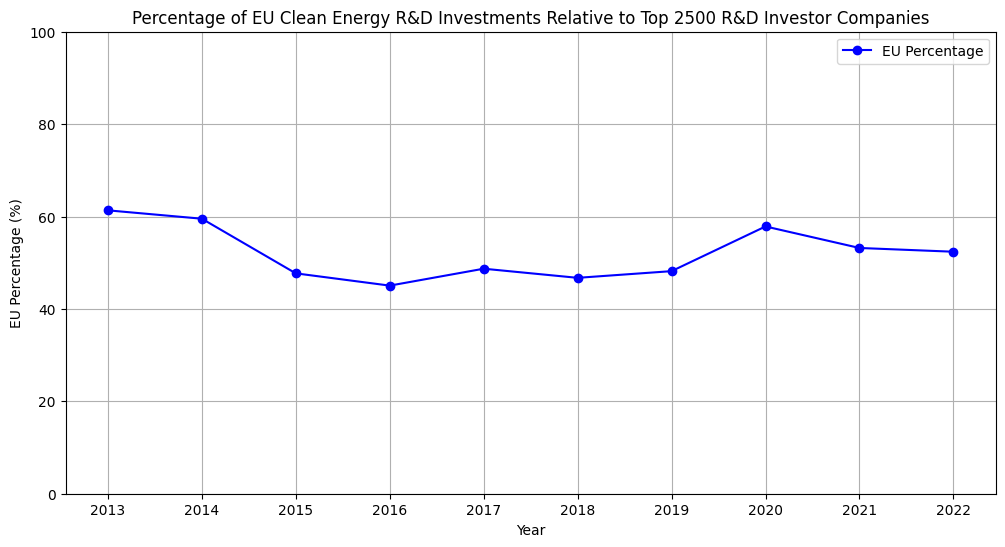

In [19]:
import matplotlib.pyplot as plt

# Plot the percentage of EU investments over the years
plt.figure(figsize=(12, 6))
plt.plot(years, percentage, marker='o', color='b', label='EU Percentage')

# Add labels and title
plt.title('Percentage of EU Clean Energy R&D Investments Relative to Top 2500 R&D Investor Companies')
plt.xlabel('Year')
plt.ylabel('EU Percentage (%)')
plt.grid(True)
plt.ylim(0, 100)
plt.xticks(years)

# Show the plot
plt.legend()
plt.show()
